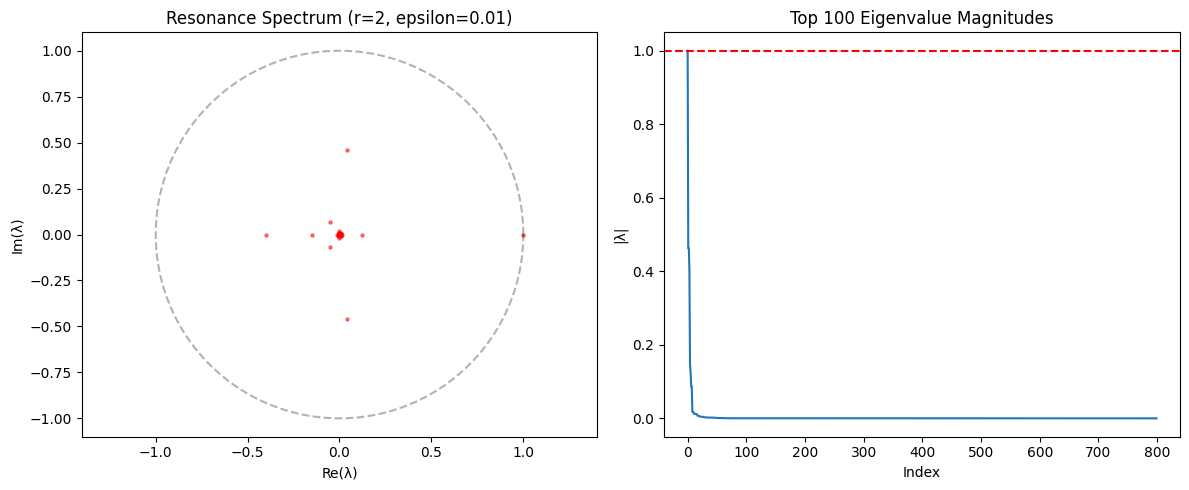

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 构造带“扩散”的转移矩阵
# ---------------------------------------------------------
r = 2
N = 800  # 稍微减小维度以加快计算，因为增加了扩散计算
edges = np.linspace(-1, 1, N + 1)
centers = (edges[:-1] + edges[1:]) / 2
dx = centers[1] - centers[0]

P = np.zeros((N, N))

# 定义扩散强度 (相当于给系统加了 epsilon 的噪声)
epsilon = 0.01 

for j in range(N):
    x_next = 1 - r * (centers[j]**2)
    
    # 核心改进：不再是 P[i,j]=1，而是计算一个高斯分布
    # 让 x_next 的能量散布到周围的格子
    if -1.1 <= x_next <= 1.1:
        # 计算所有格子中心到 x_next 的距离
        dist = np.abs(centers - x_next)
        # 高斯核扩散
        kernel = np.exp(-dist**2 / (2 * epsilon**2))
        kernel /= kernel.sum() # 归一化，保证概率守恒
        P[:, j] = kernel

# ---------------------------------------------------------
# 2. 计算并绘图
# ---------------------------------------------------------
eigvals = np.linalg.eigvals(P)

plt.figure(figsize=(12, 5))

# 子图 1: 复平面特征值分布
plt.subplot(1, 2, 1)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)
plt.scatter(eigvals.real, eigvals.imag, s=5, c='red', alpha=0.5)
plt.title(f"Resonance Spectrum (r={r}, epsilon={epsilon})")
plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.axis('equal')

# 子图 2: 模长分布
plt.subplot(1, 2, 2)
mags = np.sort(np.abs(eigvals))[::-1]
#plt.plot(mags[:100], 'o-', markersize=4)
plt.plot(mags)

plt.axhline(y=1.0, color='r', linestyle='--')
plt.title("Top 100 Eigenvalue Magnitudes")
plt.xlabel("Index")
plt.ylabel("|λ|")

plt.tight_layout()
plt.show()